# Movie Clustering — Full Pipeline
**Steps:** Install → Load → Clean → Feature Engineering → TF-IDF → LSA → KMeans → Save → Generate app.py → ZIP

## Step 1 — Install dependencies

In [23]:
%%capture
!pip install pandas scikit-learn streamlit plotly matplotlib

## Step 2 — Imports

In [24]:
import pandas as pd
import numpy as np
import json, re, os, zipfile, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print('Imports OK')

Imports OK


## Step 3 — Load dataset

In [25]:
# Load dataset from Google Drive
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# Path
DRIVE_DIR  = '/content/drive/My Drive/Web Mining'

# Auto-detect the CSV file
csv_files = [f for f in os.listdir(DRIVE_DIR) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f'No CSV file found in {DRIVE_DIR}. '
                            f'Please upload tmdb_5000_movies.csv there.')

# If multiple CSVs exist, prefer the one with "movies" in the name
preferred = [f for f in csv_files if 'movie' in f.lower()]
filename  = preferred[0] if preferred else csv_files[0]
CSV_PATH  = os.path.join(DRIVE_DIR, filename)

print(f'Found: {csv_files}')
print(f'Loading: {CSV_PATH}')

df_raw = pd.read_csv(CSV_PATH)

print(f'\nLoaded: {filename}')
print(f'Shape: {df_raw.shape}')
print('Columns:', df_raw.columns.tolist())
df_raw[['title', 'overview', 'genres', 'keywords',
        'vote_average', 'release_date', 'popularity']].head(3)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found: ['tmdb_5000_movies.csv']
Loading: /content/drive/My Drive/Web Mining/tmdb_5000_movies.csv

Loaded: tmdb_5000_movies.csv
Shape: (4803, 20)
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


,title,overview,genres,keywords,vote_average,release_date,popularity
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",7.2,2009-12-10,150.437577
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",6.9,2007-05-19,139.082615
2,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",6.3,2015-10-26,107.376788


## Step 4 — Data Cleaning
We clean the raw data in a dedicated step before any feature engineering.
Each filter is printed so you can see exactly how many rows it removes.

In [26]:
df = df_raw.copy()
print(f'Starting with {len(df):,} rows\n')

# 1. Remove duplicate titles (keep first occurrence)
before = len(df)
df = df.drop_duplicates(subset='title', keep='first')
print(f'[1] Remove duplicate titles:        -{before - len(df):>4} rows → {len(df):,} remain')

# 2. Drop rows with missing overview
before = len(df)
df = df.dropna(subset=['overview'])
print(f'[2] Drop missing overview:           -{before - len(df):>4} rows → {len(df):,} remain')

# 3. Drop overviews that are too short (< 20 chars)
before = len(df)
df = df[df['overview'].str.strip().str.len() >= 20]
print(f'[3] Drop very short overviews (<20): -{before - len(df):>4} rows → {len(df):,} remain')

# 4. Drop rows with impossible/missing vote_average
before = len(df)
df = df.dropna(subset=['vote_average'])
df = df[df['vote_average'].between(0, 10)]
print(f'[4] Drop bad vote_average:           -{before - len(df):>4} rows → {len(df):,} remain')

# 5. Drop rows with very few votes (unreliable ratings)
#MIN_VOTES = 10
#before = len(df)
#df = df[df['vote_count'].fillna(0) >= MIN_VOTES]
#print(f'[5] Drop movies with <{MIN_VOTES} votes:      -{before - len(df):>4} rows → {len(df):,} remain')

# 6. Normalise text fields
df['overview'] = df['overview'].str.strip()
df['title']    = df['title'].str.strip()

# 7. Parse release_date → year (fill missing as 0)
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year.fillna(0).astype(int)

# 8. Fill remaining NaNs in numeric cols
df['popularity']   = df['popularity'].fillna(0)
df['vote_average'] = df['vote_average'].fillna(0)

df = df.reset_index(drop=True)

print(f'\n Clean dataset: {len(df):,} movies ready for modelling')
print(f'   Null counts in key columns:')
print(df[['title','overview','vote_average','popularity','year']].isnull().sum().to_string())

Starting with 4,803 rows

[1] Remove duplicate titles:        -   3 rows → 4,800 remain
[2] Drop missing overview:           -   3 rows → 4,797 remain
[3] Drop very short overviews (<20): -   1 rows → 4,796 remain
[4] Drop bad vote_average:           -   0 rows → 4,796 remain

 Clean dataset: 4,796 movies ready for modelling
   Null counts in key columns:
title           0
overview        0
vote_average    0
popularity      0
year            0


## Step 5 — Feature engineering (text soup)

In [27]:
def extract_names(json_str, field='name', limit=5):
    """Parse a JSON list-of-dicts column and return space-joined names."""
    try:
        return ' '.join([x[field] for x in json.loads(json_str)[:limit]])
    except Exception:
        return ''

def clean_text(text):
    """Lowercase and remove non-alpha characters."""
    if not isinstance(text, str):
        return ''
    return re.sub(r'[^a-z\s]', ' ', text.lower()).strip()

# Parse JSON genre/keyword columns
df['genres_text']   = df['genres'].apply(extract_names)
df['keywords_text'] = df['keywords'].apply(extract_names, limit=10)

# Build weighted text soup:
#   overview ×1  |  genres ×3 (strong signal)  |  keywords ×2
df['soup'] = (
    df['overview'].apply(clean_text) + ' ' +
    (df['genres_text'].apply(clean_text)   + ' ') * 3 +
    (df['keywords_text'].apply(clean_text) + ' ') * 2
)

print(f'Soup built for {len(df):,} movies')
print('\nSample (first movie):')
print(df['soup'].iloc[0][:300])

Soup built for 4,796 movies

Sample (first movie):
in the   nd century  a paraplegic marine is dispatched to the moon pandora on a unique mission  but becomes torn between following orders and protecting an alien civilization action adventure fantasy science fiction action adventure fantasy science fiction action adventure fantasy science fiction cu


## Step 6 — TF-IDF vectorisation

In [28]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    min_df=2
)
tfidf_matrix = tfidf.fit_transform(df['soup'])
print(f'TF-IDF matrix: {tfidf_matrix.shape}  (movies × terms)')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')

TF-IDF matrix: (4796, 8000)  (movies × terms)
Vocabulary size: 8,000


## Step 7 — Dimensionality reduction with LSA (TruncatedSVD)

In [29]:
# 100 dims for clustering (captures semantic structure)
svd = TruncatedSVD(n_components=100, random_state=42)
X   = normalize(svd.fit_transform(tfidf_matrix))

# 2 dims for scatter-plot visualisation
svd2d = TruncatedSVD(n_components=2, random_state=42)
X_2d  = svd2d.fit_transform(tfidf_matrix)
df['x'] = X_2d[:, 0]
df['y'] = X_2d[:, 1]

print(f'LSA (100d) explained variance: {svd.explained_variance_ratio_.sum():.1%}')
print(f'Clustering matrix shape: {X.shape}')

LSA (100d) explained variance: 21.0%
Clustering matrix shape: (4796, 100)


## Step 8 — Find optimal K (Elbow + Silhouette)

  k= 4  inertia=3,937  silhouette=0.0542
  k= 5  inertia=3,833  silhouette=0.0630
  k= 6  inertia=3,745  silhouette=0.0720
  k= 7  inertia=3,651  silhouette=0.0795
  k= 8  inertia=3,586  silhouette=0.0805
  k= 9  inertia=3,521  silhouette=0.0829
  k=10  inertia=3,449  silhouette=0.0907
  k=11  inertia=3,394  silhouette=0.0949
  k=12  inertia=3,338  silhouette=0.0972
  k=13  inertia=3,292  silhouette=0.0964
  k=14  inertia=3,243  silhouette=0.0994
  k=15  inertia=3,187  silhouette=0.1070


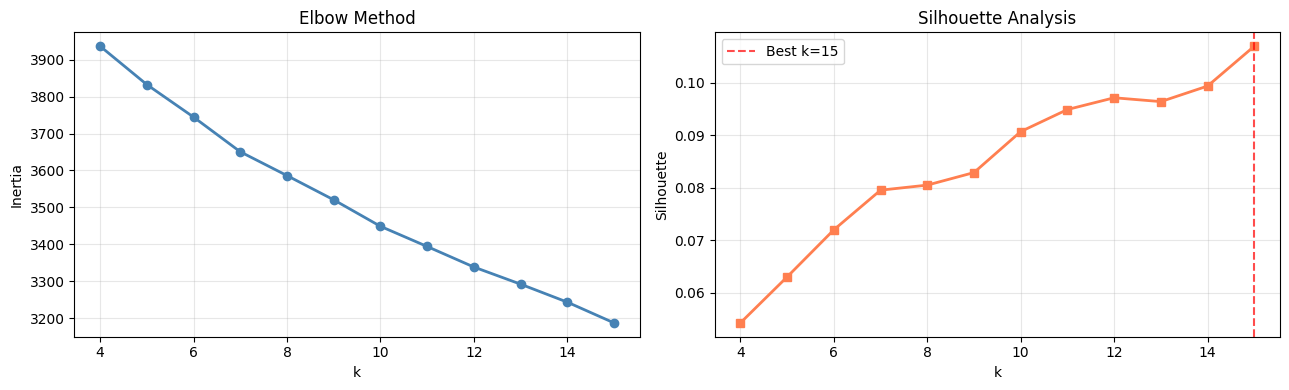


 Best k by silhouette: 15


In [30]:
K_RANGE = range(4, 16)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    s = silhouette_score(X, lbl, sample_size=1000, random_state=42)
    silhouettes.append(s)
    print(f'  k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={s:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(K_RANGE), inertias, 'o-', color='steelblue', lw=2)
ax1.set(xlabel='k', ylabel='Inertia', title='Elbow Method'); ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, 's-', color='coral', lw=2)
ax2.set(xlabel='k', ylabel='Silhouette', title='Silhouette Analysis'); ax2.grid(alpha=0.3)
best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
ax2.axvline(best_k, color='red', ls='--', alpha=0.7, label=f'Best k={best_k}')
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\n Best k by silhouette: {best_k}')

## Step 9 — Final KMeans clustering

In [31]:
K = best_k

kmeans = KMeans(n_clusters=K, init='k-means++', n_init=20, max_iter=500, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

final_sil = silhouette_score(X, df['cluster'], sample_size=1500, random_state=42)
print(f'Final model — k={K}, silhouette={final_sil:.4f}')
print('\nCluster sizes:')
print(df['cluster'].value_counts().sort_index().to_string())

Final model — k=15, silhouette=0.1082

Cluster sizes:
cluster
0     270
1     281
2     514
3     385
4     334
5     519
6     227
7     112
8     252
9     367
10    493
11    326
12    235
13    319
14    162


## Step 10 — Auto-label clusters (top TF-IDF terms)

In [32]:
feature_names  = np.array(tfidf.get_feature_names_out())
cluster_labels = {}

for c in range(K):
    idx      = df[df['cluster'] == c].index
    centroid = np.asarray(tfidf_matrix[idx].mean(axis=0)).ravel()
    top_terms = ', '.join(feature_names[centroid.argsort()[::-1][:5]])
    cluster_labels[c] = top_terms
    print(f'Cluster {c:2d} ({len(idx):4d} movies): {top_terms}')

df['cluster_keywords'] = df['cluster'].map(cluster_labels)

Cluster  0 ( 270 movies): mystery, mystery thriller, drama mystery, thriller, horror mystery
Cluster  1 ( 281 movies): comedy comedy, comedy, duringcreditsstinger, school, film
Cluster  2 ( 514 movies): science fiction, fiction, science, action, fiction action
Cluster  3 ( 385 movies): drama romance, romance, drama, romance drama, comedy drama
Cluster  4 ( 334 movies): fantasy, adventure, action, comedy, fantasy action
Cluster  5 ( 519 movies): crime, crime drama, thriller, thriller crime, comedy crime
Cluster  6 ( 227 movies): comedy drama, drama comedy, comedy, drama, film
Cluster  7 ( 112 movies): documentary, documentary documentary, documentary music, music, music documentary
Cluster  8 ( 252 movies): comedy romance, romance, comedy, romance comedy, drama comedy
Cluster  9 ( 367 movies): drama drama, drama, film, independent, independent film
Cluster 10 ( 493 movies): thriller, action, drama thriller, adventure, drama
Cluster 11 ( 326 movies): horror, horror thriller, thriller, th

## Step 11 — Cluster scatter plot

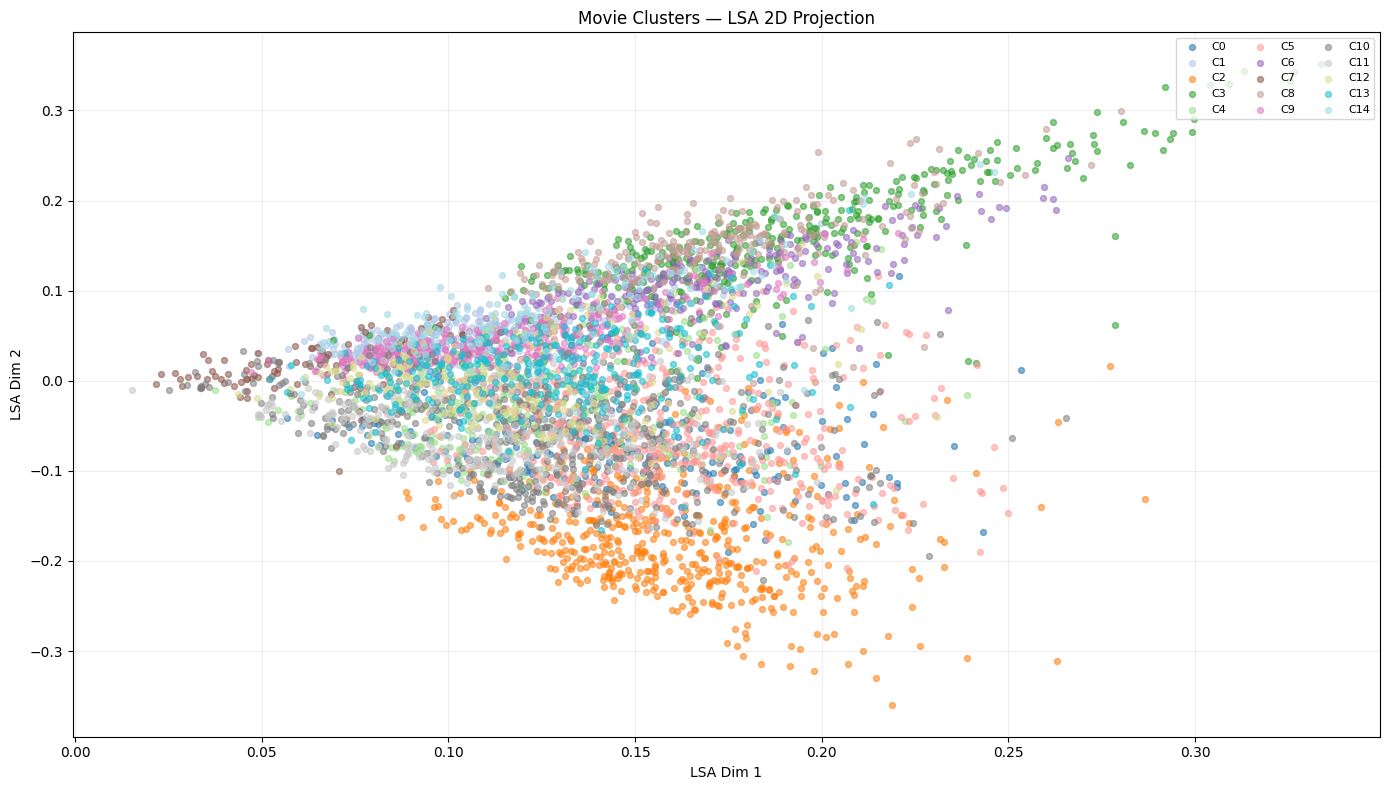

In [33]:
fig, ax = plt.subplots(figsize=(14, 8))
colors  = cm.tab20(np.linspace(0, 1, K))
for c in range(K):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask,'x'], df.loc[mask,'y'],
               color=colors[c], alpha=0.55, s=18, label=f'C{c}')
ax.set(title='Movie Clusters — LSA 2D Projection', xlabel='LSA Dim 1', ylabel='LSA Dim 2')
ax.legend(loc='upper right', ncol=3, fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

## Step 12 — Save artefacts

In [34]:
os.makedirs('app_data', exist_ok=True)

save_cols = ['title','overview','genres_text','keywords_text',
             'vote_average','popularity','year',
             'cluster','cluster_keywords','x','y']
df[save_cols].to_csv('app_data/movies_clustered.csv', index=False)

with open('app_data/cluster_labels.json', 'w') as f:
    json.dump({str(k): v for k, v in cluster_labels.items()}, f, indent=2)

with open('app_data/models.pkl', 'wb') as f:
    pickle.dump({'tfidf': tfidf, 'svd': svd, 'kmeans': kmeans,
                 'svd2d': svd2d, 'K': K}, f)

print('Saved:', os.listdir('app_data'))

Saved: ['cluster_labels.json', 'models.pkl', 'movies_clustered.csv']


## Step 13 — Generate `app.py`

In [35]:
APP_CODE = '''
import streamlit as st
import pandas as pd
import json
import plotly.express as px

st.set_page_config(
    page_title="Movie Cluster Explorer",
    page_icon="🎬",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
@import url('https://cdn.jsdelivr.net/npm/@tabler/icons-webfont@latest/tabler-icons.min.css');

html, body, [class*="css"] { font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; }
.main { background: #f5f5f7; }
.block-container { padding: 0 !important; max-width: 100% !important; }

/* topbar */
.topbar {
    background: #4B3FBF;
    padding: 14px 24px;
    display: flex;
    align-items: center;
    justify-content: space-between;
}
.topbar-left { display: flex; align-items: center; gap: 12px; }
.logo-box {
    width: 40px; height: 40px;
    background: rgba(255,255,255,0.15);
    border-radius: 8px;
    display: flex; align-items: center; justify-content: center;
    font-size: 20px;
}
.topbar-title { color: #fff; font-size: 18px; font-weight: 600; margin: 0; }
.topbar-sub { color: rgba(255,255,255,0.6); font-size: 12px; margin: 0; }
.topbar-right { display: flex; gap: 8px; align-items: center; }
.tbadge {
    background: rgba(255,255,255,0.12);
    border: 1px solid rgba(255,255,255,0.2);
    border-radius: 8px;
    padding: 6px 14px;
    color: #fff;
    font-size: 12px;
}
.tbadge b { font-size: 14px; }

/* sidebar */
section[data-testid="stSidebar"] { background: #fff !important; border-right: 1px solid #e5e5e5; }
section[data-testid="stSidebar"] .block-container { padding: 1.5rem 1rem !important; }

/* cluster section */
.cluster-card {
    background: #fff;
    border: 1px solid #e5e7eb;
    border-radius: 14px;
    margin-bottom: 16px;
    overflow: hidden;
}
.cluster-header {
    display: flex;
    align-items: center;
    gap: 12px;
    padding: 14px 18px;
    border-bottom: 1px solid #f0f0f0;
}
.cluster-num {
    width: 36px; height: 36px;
    border-radius: 8px;
    display: flex; align-items: center; justify-content: center;
    font-size: 15px; font-weight: 600;
}
.cluster-name { font-size: 14px; font-weight: 600; color: #111; margin: 0; }
.cluster-meta { font-size: 11px; color: #888; margin: 0; }
.movie-grid { display: grid; grid-template-columns: repeat(4, 1fr); gap: 0; }
.movie-tile {
    padding: 12px;
    border-right: 1px solid #f0f0f0;
    cursor: pointer;
}
.movie-tile:last-child { border-right: none; }
.movie-poster {
    width: 100%;
    aspect-ratio: 2/3;
    border-radius: 8px;
    margin-bottom: 8px;
    display: flex; align-items: center; justify-content: center;
    font-size: 28px;
    overflow: hidden;
    object-fit: cover;
}
.movie-title { font-size: 12px; font-weight: 600; color: #111; margin: 0 0 3px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
.movie-meta { font-size: 11px; color: #888; }

/* dist bar */
.dist-row { margin-bottom: 12px; }
.dist-label { display: flex; justify-content: space-between; font-size: 12px; color: #333; margin-bottom: 4px; }
.dist-pct { color: #888; }
.bar-track { height: 5px; background: #f0f0f0; border-radius: 999px; overflow: hidden; }
.bar-fill { height: 100%; border-radius: 999px; }

h1, h2, h3 { color: #111 !important; }
</style>
""", unsafe_allow_html=True)

CLUSTER_COLORS = [
    {"bg":"#EEEDFE","text":"#3C3489","bar":"#7F77DD","label":"Action & Adventure"},
    {"bg":"#FBEAF0","text":"#72243E","bar":"#D4537E","label":"Drama & Romance"},
    {"bg":"#E6F1FB","text":"#0C447C","bar":"#378ADD","label":"Sci-Fi & Thriller"},
    {"bg":"#E1F5EE","text":"#085041","bar":"#1D9E75","label":"Comedy"},
    {"bg":"#FAECE7","text":"#712B13","bar":"#D85A30","label":"Horror & Mystery"},
    {"bg":"#FAEEDA","text":"#633806","bar":"#BA7517","label":"Animation & Family"},
    {"bg":"#F1EFE8","text":"#444441","bar":"#888780","label":"Documentary"},
    {"bg":"#EAF3DE","text":"#27500A","bar":"#639922","label":"War & History"},
]

@st.cache_data
def load_data():
    df = pd.read_csv("app_data/movies_clustered.csv")
    with open("app_data/cluster_labels.json") as f:
        labels = json.load(f)
    return df, {int(k): v for k, v in labels.items()}

df, cluster_labels = load_data()
K = df["cluster"].nunique()

# ── Topbar ────────────────────────────────────────────────────────────────
st.markdown(f"""
<div class="topbar">
  <div class="topbar-left">
    <div class="logo-box">🎬</div>
    <div>
      <p class="topbar-title">Movie Clusters</p>
      <p class="topbar-sub">Grouping movies by text similarity using K-Means clustering</p>
    </div>
  </div>
  <div class="topbar-right">
    <div class="tbadge">Movies: <b>{len(df):,}</b></div>
    <div class="tbadge">Clusters: <b>{K}</b></div>
  </div>
</div>
""", unsafe_allow_html=True)

# ── Sidebar ───────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("### Cluster distribution")

    cluster_sizes = df["cluster"].value_counts().sort_index()
    total = len(df)
    for c in range(K):
        count = cluster_sizes.get(c, 0)
        pct = count / total * 100
        col = CLUSTER_COLORS[c % len(CLUSTER_COLORS)]
        label = col["label"]
        st.markdown(f"""
        <div class="dist-row">
          <div class="dist-label"><span>{label}</span><span class="dist-pct">{count:,} ({pct:.0f}%)</span></div>
          <div class="bar-track"><div class="bar-fill" style="width:{pct}%;background:{col['bar']}"></div></div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("---")
    min_rating = st.slider("Min rating", 0.0, 10.0, 5.0, step=0.5)
    year_min = int(df["year"].replace(0, pd.NA).dropna().min())
    year_max = int(df["year"].max())
    year_range = st.slider("Release year", year_min, year_max, (year_min, year_max))
    search_q = st.text_input("🔍 Search title / keyword", "")

    st.markdown("---")
    if st.button("🔄 Refresh"):
        st.cache_data.clear()
        st.rerun()

# ── Filter ────────────────────────────────────────────────────────────────
filt = (
    (df["vote_average"] >= min_rating) &
    (df["year"].between(*year_range) | (df["year"] == 0))
)
if search_q.strip():
    q = search_q.strip().lower()
    filt &= (
        df["title"].str.lower().str.contains(q, na=False) |
        df["overview"].str.lower().str.contains(q, na=False) |
        df["genres_text"].str.lower().str.contains(q, na=False)
    )
view = df[filt].copy()

# ── Summary metrics ───────────────────────────────────────────────────────
st.markdown("<div style='padding: 16px 24px 0'>", unsafe_allow_html=True)
c1, c2, c3, c4 = st.columns(4)
c1.metric("Movies shown", f"{len(view):,}")
c2.metric("Clusters", view["cluster"].nunique())
c3.metric("Avg rating", f"{view['vote_average'].mean():.2f}" if len(view) else "—")
c4.metric("Year range", f"{year_range[0]} – {year_range[1]}")
st.markdown("</div>", unsafe_allow_html=True)

# ── Tabs ──────────────────────────────────────────────────────────────────
tab1, tab2, tab3 = st.tabs(["🗂 Cluster view", "📊 Scatter plot", "📈 Stats"])

# ── Tab 1: Cluster cards ──────────────────────────────────────────────────
with tab1:
    for c in sorted(view["cluster"].unique()):
        col = CLUSTER_COLORS[c % len(CLUSTER_COLORS)]
        group = view[view["cluster"] == c].sort_values("vote_average", ascending=False)
        kw = cluster_labels.get(c, "")
        avg_r = group["vote_average"].mean()

        st.markdown(f"""
        <div class="cluster-card">
          <div class="cluster-header">
            <div class="cluster-num" style="background:{col['bg']};color:{col['text']}">{len(group)}</div>
            <div>
              <p class="cluster-name">{col['label']}</p>
              <p class="cluster-meta">{len(group):,} movies &middot; avg rating {avg_r:.1f} &middot; {kw}</p>
            </div>
          </div>
          <div class="movie-grid">
        """, unsafe_allow_html=True)

        for _, row in group.head(4).iterrows():
            year_str = str(int(row.year)) if row.year > 0 else "—"
            st.markdown(f"""
            <div class="movie-tile">
              <div class="movie-poster" style="background:{col['bg']}">🎬</div>
              <p class="movie-title">{row.title}</p>
              <p class="movie-meta">⭐ {row.vote_average:.1f} · {year_str}</p>
            </div>
            """, unsafe_allow_html=True)

        st.markdown("</div></div>", unsafe_allow_html=True)

# ── Tab 2: Scatter ────────────────────────────────────────────────────────
with tab2:
    if view.empty:
        st.warning("No movies match the current filters.")
    else:
        v2 = view.copy()
        v2["cluster_str"] = v2["cluster"].astype(str)
        PALETTE = [c["bar"] for c in CLUSTER_COLORS]
        fig = px.scatter(
            v2, x="x", y="y", color="cluster_str",
            hover_name="title",
            hover_data={"vote_average": True, "year": True, "genres_text": True,
                        "x": False, "y": False, "cluster_str": False},
            color_discrete_sequence=PALETTE,
            labels={"cluster_str": "Cluster", "vote_average": "Rating", "genres_text": "Genres"},
            template="plotly_white", height=560
        )
        fig.update_traces(marker=dict(size=6, opacity=0.75))
        fig.update_layout(xaxis=dict(showgrid=False, zeroline=False, title=""),
                          yaxis=dict(showgrid=False, zeroline=False, title=""))
        st.plotly_chart(fig, use_container_width=True)

# ── Tab 3: Stats ──────────────────────────────────────────────────────────
with tab3:
    ca, cb = st.columns(2)
    PALETTE = [c["bar"] for c in CLUSTER_COLORS]
    with ca:
        st.markdown("#### Movies per cluster")
        sizes = view.groupby("cluster").size().reset_index(name="count")
        fig_b = px.bar(sizes, x="cluster", y="count", color="cluster",
                       color_discrete_sequence=PALETTE, template="plotly_white",
                       labels={"cluster": "Cluster", "count": "# Movies"}, height=320)
        fig_b.update_layout(showlegend=False)
        st.plotly_chart(fig_b, use_container_width=True)
    with cb:
        st.markdown("#### Avg rating per cluster")
        avg_r = view.groupby("cluster")["vote_average"].mean().reset_index()
        fig_r = px.bar(avg_r, x="cluster", y="vote_average", color="cluster",
                       color_discrete_sequence=PALETTE, template="plotly_white",
                       labels={"cluster": "Cluster", "vote_average": "Avg Rating"}, height=320)
        fig_r.update_layout(showlegend=False)
        st.plotly_chart(fig_r, use_container_width=True)

    summary = (
        view.groupby("cluster")
            .agg(movies=("title","count"),
                 avg_rating=("vote_average", lambda x: round(x.mean(),2)),
                 avg_year=("year", lambda x: int(x[x>0].mean()) if (x>0).any() else 0),
                 top_keywords=("cluster_keywords","first"))
            .reset_index()
    )
    st.dataframe(summary, use_container_width=True, hide_index=True)

st.markdown("---")
st.caption("Dataset: TMDB 5000 · TF-IDF (8k terms, bigrams) → TruncatedSVD/LSA (100d) → KMeans++")
'''

with open('app.py', 'w') as f:
    f.write(APP_CODE)
print('app.py written ✔')


app.py written ✔


## Step 13.5 — Generate `index.html`
Static landing page matching the Streamlit app design, ready for GitHub Pages.

In [42]:
import pandas as pd
import json
from collections import Counter
import re

# Load the saved data
df = pd.read_csv('app_data/movies_clustered.csv')
with open('app_data/cluster_labels.json') as f:
    cluster_labels_raw = json.load(f)

# Junk words to always filter out
JUNK = {
    'duringcreditsstinger','aftercreditsstinger','creditsstinger',
    'stinger','credits','based','novel','comic','nudity','female',
    'violence','death','blood','drug','sex','murder','kill','killing',
    'woman','man','boy','girl','good','bad','new','one','two','three',
    'first','second','third','time','life','story','world','title',
    'scene','sequel','movie','film','series','part','year','make',
    'character','place','thing','back','name','take','come','much',
    'many','well','also','just','very','real','true','old','young',
    'big','small','long','short','high','low','day','night','home',
    'house','friend','people','person','group','team','live','love',
    'find','know','want','need','help','play','work','turn','give',
    'show','look','feel','seem','keep','call','used','uses','have',
    'will','with','this','that','from','they','them','than','then',
    'when','what','which','who','whom','whose','where','while',
    'about','after','again','along','among','around','away',
    'between','both','down','during','each','even','ever','every',
    'following','found','goes','gone','getting','given','goes',
    'had','has','having','himself','herself','itself','into','more',
    'most','never','only','other','over','same','some','still',
    'such','through','under','until','upon','using','were','without',
}

def best_label_for_cluster(cluster_df):
    word_counts = Counter()

    for kw_str in cluster_df['cluster_keywords'].dropna():
        # split by comma to get phrases, then split each phrase into words
        phrases = [p.strip().lower() for p in kw_str.split(',')]
        for phrase in phrases:
            # split phrase into individual words
            words = re.split(r'[\s\-_]+', phrase)
            for w in words:
                w = w.strip()
                # filter: must be longer than 3 chars, not junk, not numeric
                if w and len(w) > 3 and w not in JUNK and not any(ch.isdigit() for ch in w):
                    word_counts[w] += 1

    if not word_counts:
        return 'Mixed'

    # pick top words, skipping any that are too similar to already chosen ones
    chosen = []
    for word, _ in word_counts.most_common(50):
        # skip if this word contains or is contained in an already chosen word
        too_similar = False
        for c in chosen:
            if word in c or c in word:
                too_similar = True
                break
            # also skip if words differ only by an 's' suffix (plural)
            if word.rstrip('s') == c.rstrip('s'):
                too_similar = True
                break
        if not too_similar:
            chosen.append(word)
        if len(chosen) == 2:
            break

    if not chosen:
        return 'Mixed'

    return ' & '.join(w.capitalize() for w in chosen)

# Build smart labels per cluster
smart_labels = {}
for c in df['cluster'].unique():
    smart_labels[int(c)] = best_label_for_cluster(df[df['cluster'] == c])

# Print preview so you can verify — manually fix any that still look off
print("Cluster labels preview:")
for c in sorted(smart_labels.keys()):
    count = len(df[df['cluster'] == c])
    print(f"  Cluster {c:2d} ({count:4d} movies): {smart_labels[c]}")

# ── Manual overrides — add lines here if any label still looks wrong ──────
# smart_labels[3] = 'Romantic Drama'
# smart_labels[7] = 'Science Fiction'

# Embed smart labels
df['smart_label'] = df['cluster'].map(smart_labels)

movies_json = df[['title','vote_average','year','cluster','smart_label']].rename(columns={
    'vote_average':'rating',
    'smart_label':'label'
}).to_json(orient='records')

INDEX_HTML = f'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1.0"/>
<title>Movie Cluster Explorer</title>
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;background:#f0f0f5;color:#111;min-height:100vh;display:flex;flex-direction:column}}
.topbar{{background:linear-gradient(135deg,#4B3FBF,#7B5EA7);padding:18px 28px;display:flex;align-items:center;gap:14px;box-shadow:0 2px 12px rgba(75,63,191,0.3)}}
.logo-box{{width:44px;height:44px;background:rgba(255,255,255,0.15);border-radius:12px;display:flex;align-items:center;justify-content:center;font-size:24px;flex-shrink:0}}
.topbar-text h1{{color:#fff;font-size:20px;font-weight:700;margin-bottom:2px}}
.topbar-text p{{color:rgba(255,255,255,0.65);font-size:12px}}
.body{{display:flex;flex:1;gap:0;min-height:calc(100vh - 80px)}}
.sidebar{{width:260px;min-width:260px;background:#fff;border-right:1px solid #e5e7eb;display:flex;flex-direction:column;position:sticky;top:0;height:100vh}}
.sidebar-top{{padding:18px 16px 10px;border-bottom:1px solid #f0f0f0}}
.sidebar-top h3{{font-size:13px;font-weight:700;color:#111;margin-bottom:4px}}
.hint-box{{background:#F5F4FF;border:1px solid #DDD9FF;border-radius:8px;padding:8px 10px;margin-top:10px;font-size:11px;color:#5547CC;line-height:1.6}}
.hint-box b{{display:block;margin-bottom:4px;font-size:11px}}
.hint-row{{display:flex;align-items:flex-start;gap:6px;margin-bottom:3px}}
.hint-row:last-child{{margin-bottom:0}}
.sidebar-scroll{{flex:1;overflow-y:auto;padding:10px 16px 16px}}
.dist-row{{margin-bottom:3px}}
.dist-btn{{width:100%;background:none;border:none;text-align:left;cursor:pointer;padding:8px 10px;border-radius:8px;display:flex;align-items:center;justify-content:space-between;gap:8px;transition:background .15s}}
.dist-btn:hover{{background:#f5f5fb}}
.dist-btn.active{{background:#EEEDFE}}
.dist-name{{font-size:12px;color:#333;font-weight:500;flex:1;min-width:0;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}}
.dist-btn.active .dist-name{{color:#3C3489;font-weight:600}}
.dist-count{{font-size:11px;color:#aaa;flex-shrink:0}}
.dist-btn.active .dist-count{{color:#7F77DD}}
.bar-track{{height:3px;background:#f0f0f0;border-radius:999px;overflow:hidden;margin:0 10px 5px}}
.bar-fill{{height:100%;border-radius:999px}}
.main{{flex:1;padding:20px;display:flex;flex-direction:column;gap:14px;overflow-y:auto}}
.metrics{{display:grid;grid-template-columns:repeat(3,1fr);gap:10px}}
.metric{{background:#fff;border:1px solid #e5e7eb;border-radius:12px;padding:14px 16px;display:flex;align-items:center;gap:12px}}
.metric-icon{{font-size:22px}}
.metric-label{{font-size:11px;color:#888;margin-bottom:3px}}
.metric-val{{font-size:22px;font-weight:700;color:#111}}
.cluster-card{{background:#fff;border:1px solid #e5e7eb;border-radius:14px;overflow:hidden;transition:box-shadow .2s;margin-bottom:2px}}
.cluster-card:hover{{box-shadow:0 4px 20px rgba(0,0,0,0.07)}}
.cluster-header{{display:flex;align-items:center;gap:12px;padding:14px 18px;border-bottom:1px solid #f5f5f5;cursor:pointer;transition:background .15s;user-select:none}}
.cluster-header:hover{{background:#fafafa}}
.cluster-num{{width:38px;height:38px;border-radius:10px;display:flex;align-items:center;justify-content:center;font-size:13px;font-weight:700;flex-shrink:0}}
.cluster-name{{font-size:13px;font-weight:700;color:#111;margin-bottom:2px}}
.cluster-meta{{font-size:11px;color:#999}}
.expand-hint{{font-size:10px;color:#bbb;margin-top:3px}}
.expand-icon{{margin-left:auto;font-size:20px;color:#ccc;transition:transform .25s;flex-shrink:0}}
.movies-grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:0;background:#fafafa}}
.movie-tile{{padding:12px;border-right:1px solid #f0f0f0;background:#fff}}
.movie-tile:last-child{{border-right:none}}
.poster{{width:100%;aspect-ratio:2/3;border-radius:10px;margin-bottom:8px;display:flex;align-items:center;justify-content:center;font-size:28px}}
.movie-name{{font-size:11px;font-weight:600;color:#111;margin-bottom:3px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}}
.movie-info{{font-size:10px;color:#999}}
.all-movies-panel{{display:none;border-top:1px solid #f0f0f0;background:#fafafa}}
.all-movies-panel.open{{display:block}}
.panel-inner{{padding:16px;max-height:460px;overflow-y:auto}}
.panel-header{{display:flex;align-items:center;justify-content:space-between;margin-bottom:14px}}
.panel-title{{font-size:13px;font-weight:700;color:#111}}
.panel-count{{font-size:11px;color:#999;margin-left:6px}}
.close-btn{{background:#f0f0f5;border:none;border-radius:6px;font-size:12px;color:#888;cursor:pointer;padding:5px 12px;transition:background .15s}}
.close-btn:hover{{background:#e5e5ef;color:#333}}
.all-movies-grid{{display:grid;grid-template-columns:repeat(5,1fr);gap:10px}}
.all-movie-item{{display:flex;flex-direction:column}}
.all-poster{{width:100%;aspect-ratio:2/3;border-radius:8px;margin-bottom:5px;display:flex;align-items:center;justify-content:center;font-size:20px}}
.all-movie-name{{font-size:10px;font-weight:600;color:#111;margin-bottom:2px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}}
.all-movie-info{{font-size:10px;color:#aaa}}
footer{{padding:14px 28px;font-size:11px;color:#bbb;text-align:center;border-top:1px solid #e5e7eb;background:#fff}}
footer a{{color:#4B3FBF;text-decoration:none}}
::-webkit-scrollbar{{width:5px}}
::-webkit-scrollbar-track{{background:transparent}}
::-webkit-scrollbar-thumb{{background:#ddd;border-radius:99px}}
::-webkit-scrollbar-thumb:hover{{background:#bbb}}
</style>
</head>
<body>

<div class="topbar">
  <div class="logo-box">🎬</div>
  <div class="topbar-text">
    <h1>Movie Cluster Explorer</h1>
    <p>Grouping 4,800+ movies by text similarity using K-Means &amp; TF-IDF</p>
  </div>
</div>

<div class="body">
  <div class="sidebar">
    <div class="sidebar-top">
      <h3>📊 Cluster Distribution</h3>
      <div class="hint-box">
        <b>💡 How to use</b>
        <div class="hint-row"><span>👈</span><span>Click a cluster here to jump to it</span></div>
        <div class="hint-row"><span>🎬</span><span>Click a cluster title to see all its movies</span></div>
        <div class="hint-row"><span>✕</span><span>Click Close to collapse the movie list</span></div>
      </div>
    </div>
    <div class="sidebar-scroll" id="sidebar-list"></div>
  </div>

  <div class="main">
    <div class="metrics">
      <div class="metric"><span class="metric-icon">🎞️</span><div><div class="metric-label">Total Movies</div><div class="metric-val" id="m-total">—</div></div></div>
      <div class="metric"><span class="metric-icon">🗂️</span><div><div class="metric-label">Clusters</div><div class="metric-val" id="m-clusters">—</div></div></div>
      <div class="metric"><span class="metric-icon">⭐</span><div><div class="metric-label">Avg Rating</div><div class="metric-val" id="m-rating">—</div></div></div>
    </div>
    <div id="cluster-list"></div>
  </div>
</div>

<footer>
  Dataset: <a href="https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata" target="_blank">TMDB 5000 Movies</a>
  &nbsp;·&nbsp; Pipeline: TF-IDF → TruncatedSVD/LSA → KMeans++
</footer>

<script>
const PALETTES = [
  {{bg:"#EEEDFE",text:"#3C3489",bar:"#7F77DD"}},
  {{bg:"#FBEAF0",text:"#72243E",bar:"#D4537E"}},
  {{bg:"#E6F1FB",text:"#0C447C",bar:"#378ADD"}},
  {{bg:"#E1F5EE",text:"#085041",bar:"#1D9E75"}},
  {{bg:"#FAECE7",text:"#712B13",bar:"#D85A30"}},
  {{bg:"#FAEEDA",text:"#633806",bar:"#BA7517"}},
  {{bg:"#F1EFE8",text:"#444441",bar:"#888780"}},
  {{bg:"#EAF3DE",text:"#27500A",bar:"#639922"}},
  {{bg:"#FDE8F5",text:"#6B1249",bar:"#C9499A"}},
  {{bg:"#E8F4FD",text:"#0A4A6B",bar:"#2E9FD8"}},
  {{bg:"#FFF3E0",text:"#7A3E00",bar:"#F4900C"}},
  {{bg:"#F3E5F5",text:"#4A1060",bar:"#9C27B0"}},
  {{bg:"#E0F7FA",text:"#004D56",bar:"#00ACC1"}},
  {{bg:"#FCE4EC",text:"#7B1535",bar:"#E91E63"}},
  {{bg:"#F9FBE7",text:"#3A4A00",bar:"#9E9D24"}},
];

function getLabelForCluster(c){{
  const grp = groups[c]||[];
  return grp.length ? grp[0].label : 'Mixed';
}}

const movies = {movies_json};

const K = Math.max(...movies.map(m=>m.cluster))+1;
const groups = {{}};
for(let c=0;c<K;c++) groups[c]=movies.filter(m=>m.cluster===c).sort((a,b)=>b.rating-a.rating);

const clusterLabels = {{}};
for(let c=0;c<K;c++){{
  clusterLabels[c]=getLabelForCluster(c);
}}

const total=movies.length;
const avgR=(movies.reduce((s,m)=>s+m.rating,0)/total).toFixed(2);
document.getElementById('m-total').textContent    = total.toLocaleString();
document.getElementById('m-clusters').textContent = K;
document.getElementById('m-rating').textContent   = avgR;

const sidebarEl=document.getElementById('sidebar-list');
for(let c=0;c<K;c++){{
  const pal  =PALETTES[c%PALETTES.length];
  const grp  =groups[c]||[];
  const count=grp.length;
  if(!count) continue;
  const pct  =Math.round(count/total*100);
  const label=clusterLabels[c];
  const wrap =document.createElement('div');
  wrap.className='dist-row';
  wrap.innerHTML=`
    <button class="dist-btn" data-c="${{c}}" title="Jump to ${{label}}">
      <span class="dist-name">${{label}}</span>
      <span class="dist-count">${{count.toLocaleString()}} (${{pct}}%)</span>
    </button>
    <div class="bar-track"><div class="bar-fill" style="width:${{Math.max(pct,1)}}%;background:${{pal.bar}}"></div></div>`;
  sidebarEl.appendChild(wrap);
}}

const listEl=document.getElementById('cluster-list');
for(let c=0;c<K;c++){{
  const pal  =PALETTES[c%PALETTES.length];
  const grp  =groups[c]||[];
  if(!grp.length) continue;
  const label=clusterLabels[c];
  const avgGR=(grp.reduce((s,m)=>s+m.rating,0)/grp.length).toFixed(1);

  const previewHTML=grp.slice(0,4).map(m=>`
    <div class="movie-tile">
      <div class="poster" style="background:${{pal.bg}}">🎬</div>
      <div class="movie-name" title="${{m.title}}">${{m.title}}</div>
      <div class="movie-info">⭐ ${{m.rating.toFixed(1)}} · ${{m.year||'—'}}</div>
    </div>`).join('');

  const allHTML=grp.map(m=>`
    <div class="all-movie-item">
      <div class="all-poster" style="background:${{pal.bg}}">🎬</div>
      <div class="all-movie-name" title="${{m.title}}">${{m.title}}</div>
      <div class="all-movie-info">⭐ ${{m.rating.toFixed(1)}} · ${{m.year||'—'}}</div>
    </div>`).join('');

  const card=document.createElement('div');
  card.className='cluster-card';
  card.id=`card-${{c}}`;
  card.innerHTML=`
    <div class="cluster-header" data-c="${{c}}" role="button" tabindex="0" aria-expanded="false">
      <div class="cluster-num" style="background:${{pal.bg}};color:${{pal.text}}">${{grp.length}}</div>
      <div style="min-width:0;flex:1">
        <div class="cluster-name">${{label}}</div>
        <div class="cluster-meta">${{grp.length.toLocaleString()}} movies · avg ⭐ ${{avgGR}}</div>
        <div class="expand-hint">🎬 Click to see all movies in this cluster</div>
      </div>
      <span class="expand-icon">›</span>
    </div>
    <div class="movies-grid">${{previewHTML}}</div>
    <div class="all-movies-panel" id="panel-${{c}}">
      <div class="panel-inner">
        <div class="panel-header">
          <div><span class="panel-title">All movies — ${{label}}</span><span class="panel-count">${{grp.length}} total</span></div>
          <button class="close-btn" data-c="${{c}}">✕ Close</button>
        </div>
        <div class="all-movies-grid">${{allHTML}}</div>
      </div>
    </div>`;
  listEl.appendChild(card);
}}

sidebarEl.addEventListener('click',e=>{{
  const btn=e.target.closest('.dist-btn');
  if(!btn) return;
  const c=btn.dataset.c;
  document.querySelectorAll('.dist-btn').forEach(b=>b.classList.remove('active'));
  btn.classList.add('active');
  document.getElementById(`card-${{c}}`)?.scrollIntoView({{behavior:'smooth',block:'start'}});
}});

listEl.addEventListener('click',e=>{{
  const closeBtn=e.target.closest('.close-btn');
  if(closeBtn){{
    const c=closeBtn.dataset.c;
    document.getElementById(`panel-${{c}}`).classList.remove('open');
    document.querySelector(`.cluster-header[data-c="${{c}}"] .expand-icon`).style.transform='rotate(0deg)';
    document.querySelector(`.cluster-header[data-c="${{c}}"]`).setAttribute('aria-expanded','false');
    return;
  }}
  const hdr=e.target.closest('.cluster-header');
  if(hdr){{
    const c    =hdr.dataset.c;
    const panel=document.getElementById(`panel-${{c}}`);
    const icon =hdr.querySelector('.expand-icon');
    const open =panel.classList.toggle('open');
    icon.style.transform=open?'rotate(90deg)':'rotate(0deg)';
    hdr.setAttribute('aria-expanded',open);
  }}
}});

listEl.addEventListener('keydown',e=>{{
  if(e.key==='Enter'||e.key===' '){{
    const hdr=e.target.closest('.cluster-header');
    if(hdr) hdr.click();
  }}
}});
</script>
</body>
</html>'''

with open('index.html', 'w') as f:
    f.write(INDEX_HTML)
print('index.html written ✔')
print(f'Size: {os.path.getsize("index.html"):,} bytes')

Cluster labels preview:
  Cluster  0 ( 270 movies): Mystery & Thriller
  Cluster  1 ( 281 movies): Comedy & School
  Cluster  2 ( 514 movies): Fiction & Science
  Cluster  3 ( 385 movies): Drama & Romance
  Cluster  4 ( 334 movies): Fantasy & Action
  Cluster  5 ( 519 movies): Crime & Thriller
  Cluster  6 ( 227 movies): Comedy & Drama
  Cluster  7 ( 112 movies): Documentary & Music
  Cluster  8 ( 252 movies): Comedy & Romance
  Cluster  9 ( 367 movies): Drama & Independent
  Cluster 10 ( 493 movies): Thriller & Drama
  Cluster 11 ( 326 movies): Horror & Thriller
  Cluster 12 ( 235 movies): History & Drama
  Cluster 13 ( 319 movies): Family & Comedy
  Cluster 14 ( 162 movies): Music & Drama
index.html written ✔
Size: 457,847 bytes


## Step 14 — Generate `requirements.txt` and `.streamlit/config.toml`

In [43]:
with open('requirements.txt', 'w') as f:
    f.write('streamlit>=1.35.0\npandas>=2.0.0\nnumpy>=1.25.0\nscikit-learn>=1.4.0\nplotly>=5.20.0\n')
print('requirements.txt written')

os.makedirs('.streamlit', exist_ok=True)
with open('.streamlit/config.toml', 'w') as f:
    f.write('[theme]\nbase = "dark"\nprimaryColor = "#6c6cff"\n'
            'backgroundColor = "#0f0f13"\nsecondaryBackgroundColor = "#1a1a24"\n'
            'textColor = "#e8e8f0"\nfont = "sans serif"\n\n'
            '[server]\nheadless = true\nenableCORS = false\n')
print('.streamlit/config.toml written')

requirements.txt written
.streamlit/config.toml written


## Step 15 — Bundle into ZIP and download

In [44]:
ZIP_NAME = 'movie_clustering_app.zip'
include  = [
    'app.py',
    'requirements.txt',
    'index.html',
    '.streamlit/config.toml',
    'app_data/movies_clustered.csv',
    'app_data/cluster_labels.json',
    'app_data/models.pkl',
]

with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in include:
        if os.path.exists(path):
            zf.write(path)
            print(f'  ✔ {path}')
        else:
            print(f'  ✗ missing: {path}')

size_mb = os.path.getsize(ZIP_NAME) / 1_048_576
print(f'\n {ZIP_NAME}  ({size_mb:.1f} MB)')

try:
    from google.colab import files
    files.download(ZIP_NAME)
except ImportError:
    print(f'ZIP saved locally at: {os.path.abspath(ZIP_NAME)}')


  ✔ app.py
  ✔ requirements.txt
  ✔ index.html
  ✔ .streamlit/config.toml
  ✔ app_data/movies_clustered.csv
  ✔ app_data/cluster_labels.json
  ✔ app_data/models.pkl

 movie_clustering_app.zip  (7.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>